# ESMRMb2026 - SWEEP2 Gradient analysis -ep.02 
---------------------------------------------------
This file exists because the results've got from other script where really weird, so i decided to redo it from the beginning 

In [57]:
#================================
# CONFIGURE
#================================


import os 
import subprocess 
import nibabel as nib 
import seaborn as sns 
import numpy as np 
import pandas as pd 
import tempfile 
import glob
from nilearn import image as nlimage
import re
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_design_matrix, plot_glass_brain
import matplotlib.pyplot as plt
from nilearn.glm.second_level import SecondLevelModel
from joblib import Parallel, delayed
import warnings

vps = [i for i in range(44) if i not in [32]] 
sessions = ["ses-01", "ses-02"]
APs = ["A","B", "C"]

# Direction SET
vp_ABC=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 39, 40, 41, 43]
vp_BCA=[18, 19, 20, 21, 23, 24, 22, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 42]

TEMPLATE = r"/usr/local/fsl/data/standard/MNI152_T1_2mm_brain.nii.gz"
TEMPLATE_MASK = r"/usr/local/fsl/data/standard/MNI152_T1_2mm_brain_mask.nii.gz"

KERNEL = []
SMOOTHING = "6mm"
l2fwhm = [1.69865806, 2.54798709]   # KERNEL 4 mni space smoothing in mm l2fwhm=(4 6)

SHELLs = [0, 500, 1000, 1500, 2000, 2800]

PRJ_path = r"/home/malberti/Unix_Folders/SWEEP2"

### Coreg SHELLs to MNI space
-----------------------------

In [ ]:

for vp in vps: 
    for session in sessions: 
        for AP in APs: 
            pid = f"sub-{vp:02d}"
            subjid = f"{pid}_{session}"
            derivatives = os.path.join(PRJ_path, 'derivatives', pid, session, "dwi")

            DWIs = os.path.join(derivatives, "signal_drift", f"{subjid}_eddy-current_signal-drift_{AP}_corr.nii.gz")
            BVECs = os.path.join(derivatives, "signal_drift", f"{subjid}_dwi_eddy_corrected_{AP}_noPA.eddy_rotated_bvecs")
            BVALs = os.path.join(derivatives, "signal_drift", f"{subjid}_dwi_eddy_corrected_{AP}_noPA.bval")

            #dMRI --> MNI space coregistration + smoothing 
            coreg = os.path.join(derivatives, "coreg")  # dwi --> T1w matrix

            anat = os.path.join(PRJ_path, "derivatives", pid, "ses-02", "anat")  #, id, "mri")
            t1w = os.path.join(anat, "brain-extraction", f"{pid}_ses-02_desc-brain_t1w.nii.gz")
            t1w_mask = os.path.join(anat, "brain-extraction", f"{pid}_ses-02_desc-brain_mask.nii.gz")
            FA2t1w_matrix = os.path.join(coreg, f"{subjid}_{AP}_FA2t1w_0GenericAffine.mat")

            t1w2MNI = os.path.join(anat, "mni-registration", f"{pid}_ses-02_desc-nonlin1warp_xfm.nii.gz")  #Non sub-200_ses-02_desc-nonlin1warp_xfm linear warp 
            t1w2MNI_lin = os.path.join(anat, "mni-registration", f"{pid}_ses-02_desc-nonlin0genericaffine_xfm.mat")

            for SHELL in SHELLs: 
                out_dir = os.path.join(derivatives, "Gradient_Analysis")
                os.makedirs(out_dir, exist_ok=True)

                out_DWI = os.path.join(out_dir, f"{subjid}_signal-drift_{AP}_corr_b-{SHELL}.nii.gz")

                if SHELL > 0: 
                    subprocess.run(f"dwiextract {DWIs} -shell {SHELL} {out_DWI} -no_bzero -fslgrad {BVECs} {BVALs} -force -debug", shell=True, check=True)
                elif SHELL == 0: 
                    subprocess.run(f"dwiextract {DWIs} {out_DWI} -bzero -fslgrad {BVECs} {BVALs} -force -debug", shell=True, check=True)

                print(f"\n Subj: {pid} \n Ses: {session} \n Set: {AP} \n SHELL: {SHELL} Extracted")

                with tempfile.TemporaryDirectory() as tmp:  #coreg to MNI space each volume
                    os.makedirs(os.path.join(tmp, "smooth"), exist_ok=True)
                    subprocess.run(f"fslsplit {out_DWI} {os.path.join(tmp, 'vol')}", shell=True, check=True)
                    N_volumes = len(glob.glob(os.path.join(tmp, "vol*")))
                    count = 1

                    for volume in glob.glob(os.path.join(tmp, "vol*")): 
                        
                        subprocess.run(f"antsApplyTransforms -d 3 -e 0 -i {volume} -r {TEMPLATE} -o {volume} -n BSpline --transform {t1w2MNI} --transform {t1w2MNI_lin} --transform {FA2t1w_matrix} -v", shell=True)
                        tmp1 = os.path.join(tmp, "tt1.nii.gz")
                        tmp2 = os.path.join(tmp, "tt2.nii.gz")

                        print(f"Smoothing.... \n {count}/{N_volumes}")

                        subprocess.run(f"fslmaths {volume} -mas {TEMPLATE_MASK} -s {l2fwhm[1]} -mas {TEMPLATE_MASK} {tmp1}", shell=True)
                        subprocess.run(f"fslmaths {TEMPLATE_MASK} -s {l2fwhm[1]} -mas {TEMPLATE_MASK} {tmp2}", shell=True)
                        subprocess.run(f"fslmaths {tmp1} -div {tmp2} {volume}", shell=True)

                        count += 1

                    smoothed_volumes = " ".join(sorted(glob.glob(os.path.join(tmp, "vol*"))))

                    out_DWI_mni = os.path.join(out_dir, f"{subjid}_signal-drift_{AP}_corr_b-{SHELL}_2MNI6mm.nii.gz")
                    subprocess.run(f"fslmerge -t {out_DWI_mni} {smoothed_volumes}", shell=True, check=True)

                    print(f"\n Completed: {out_DWI_mni}")

### Compute the Average gradient ABC + GLM
------------------------------------------

In [ ]:
import os
import numpy as np
import nibabel as nib

# Prepare the images:

vp_ABC = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 39, 40, 41, 43]
vp_BCA = [18, 19, 20, 21, 23, 24, 22, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 42]

for vp in vps: 
    for session in sessions: 
        for AP in APs: 
            pid = f"sub-{vp:02d}"
            subjid = f"{pid}_{session}"
            derivatives = os.path.join(PRJ_path, 'derivatives', pid, session, "dwi")

            # We now change the AP set in order to match ABC order 
            remap = {"C": "B", "B": "A", "A": "C"}
            if vp in vp_BCA:
                new_AP = remap[AP]
            elif vp in vp_ABC:
                new_AP = AP

            for SHELL in SHELLs: 
                out_dir = os.path.join(derivatives, "Gradient_Analysis")

                DWIs_mni = nib.load(os.path.join(out_dir, f"{subjid}_signal-drift_{AP}_corr_b-{SHELL}_2MNI6mm.nii"))
                out_mean_path = os.path.join(out_dir, f"{subjid}_signal-drift_{new_AP}-{AP}_corr_b-{SHELL}_2MNI6mm-mean.nii.gz")

                data = DWIs_mni.get_fdata()
                affine, header = DWIs_mni.affine, DWIs_mni.header

                mean_img = nib.Nifti1Image(np.mean(data, axis=-1), affine=affine, header=header)  # Create an average image
                nib.save(mean_img, out_mean_path)

                print(f"\n Completed: {out_mean_path}")

# Stack all the images in few files, ready to be analyzed. 


In [ ]:

for SHELL in SHELLs:
    for session in sessions: 
        ABC_average = []  # Create two files, one has all the images from ses-01 and the other all the images for ses-02
        for vp in vps: 
            DWIs_mean = []
            for AP in APs: 
                pid = f"sub-{vp:02d}"
                subjid = f"{pid}_{session}"
                derivatives = os.path.join(PRJ_path, 'derivatives', pid, session, "dwi")

                # We now change the AP set in order to match ABC order 
                remap = {"C": "B", "B": "A", "A": "C"}
                if vp in vp_BCA:
                    new_AP = remap[AP]
                elif vp in vp_ABC:
                    new_AP = AP

                out_dir = os.path.join(derivatives, "Gradient_Analysis")
                mean_img = nib.load(os.path.join(out_dir, f"{subjid}_signal-drift_{new_AP}-{AP}_corr_b-{SHELL}_2MNI6mm-mean.nii.gz"))
                affine, header = mean_img.affine, mean_img.header
                DWIs_mean.append(mean_img.get_fdata())  # Collect A, B and C mean volumes for this vp/session

            ABC_average.append(np.mean(np.stack(DWIs_mean, axis=-1), axis=-1))  # average of A, B, C for this vp*session

        # Average image: 
        out_dir = os.path.join(PRJ_path, "Gradient_Analysis")
        os.makedirs(out_dir, exist_ok=True)

        out_DWI_mni = os.path.join(out_dir, f"{session}_signal-drift_ABC_corr_b-{SHELL}_2MNI6mm.nii.gz")
        stacked_img = nib.Nifti1Image(np.stack(ABC_average, axis=-1), affine=affine, header=header)  # 4D: one volume per vp
        nib.save(stacked_img, out_DWI_mni)  # Save one image * session * SHELL

        print(f"\n Completed: {out_DWI_mni}")


## Run GLM!!! 
-----------------------

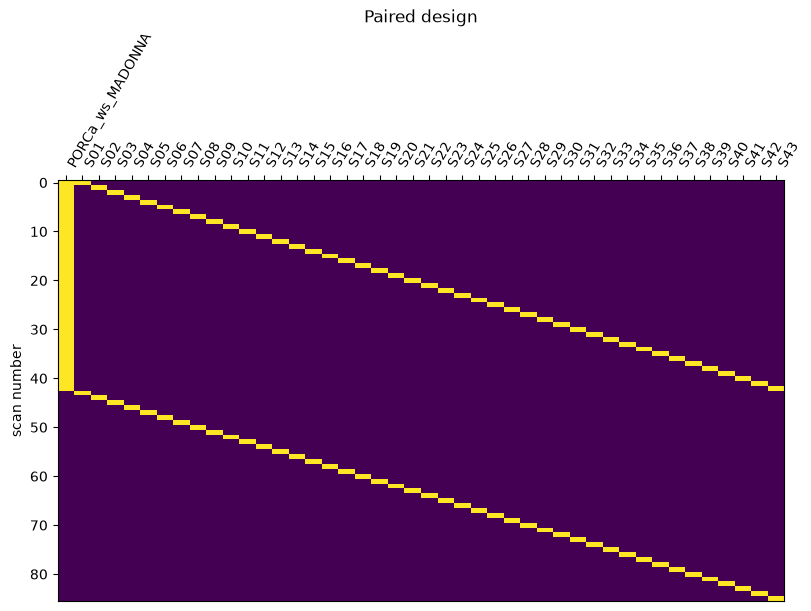

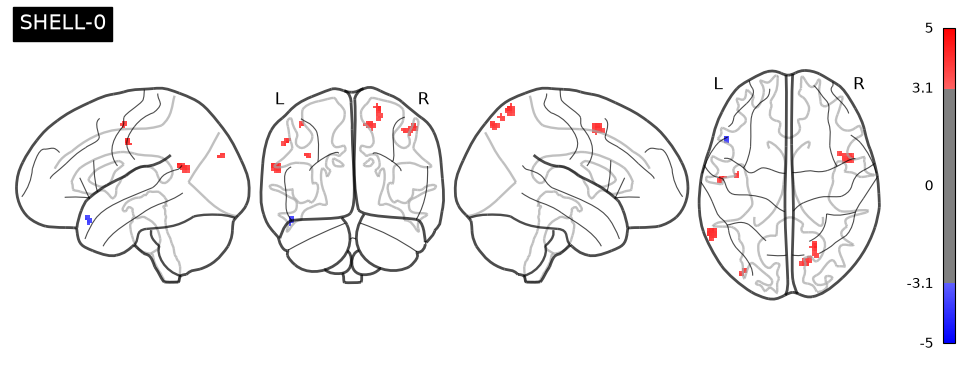

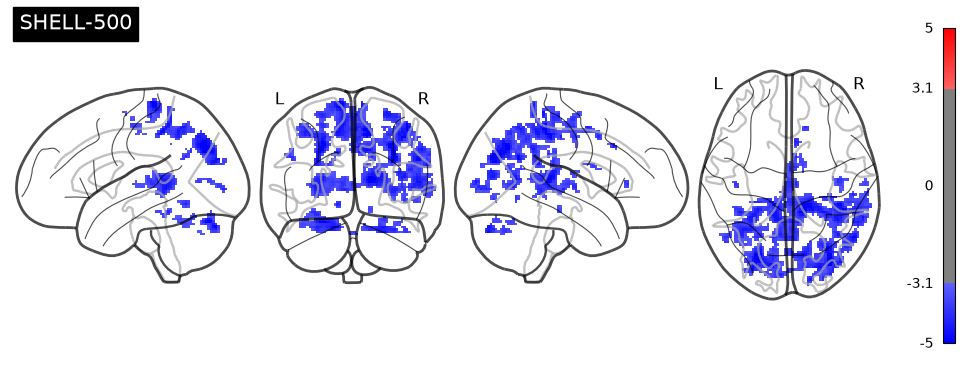

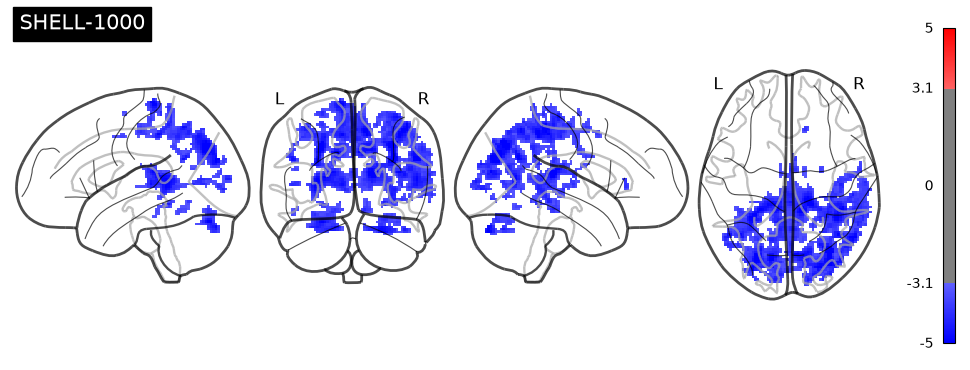

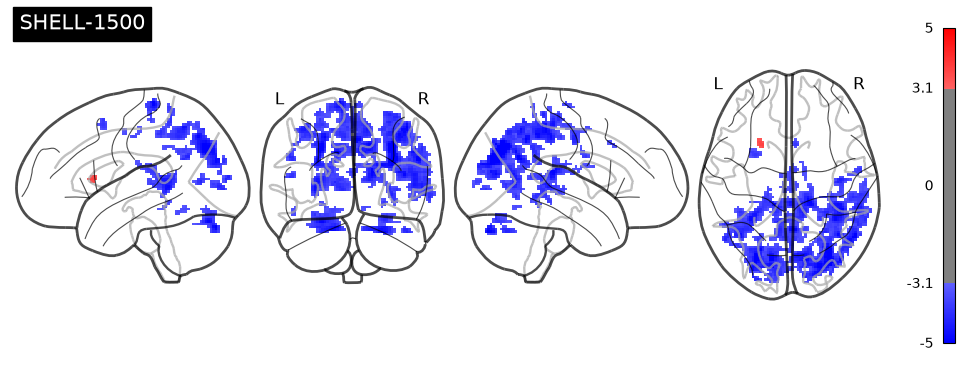

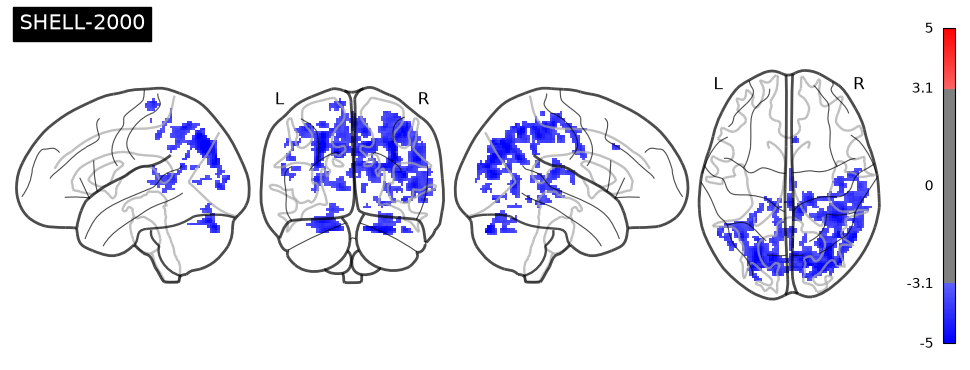

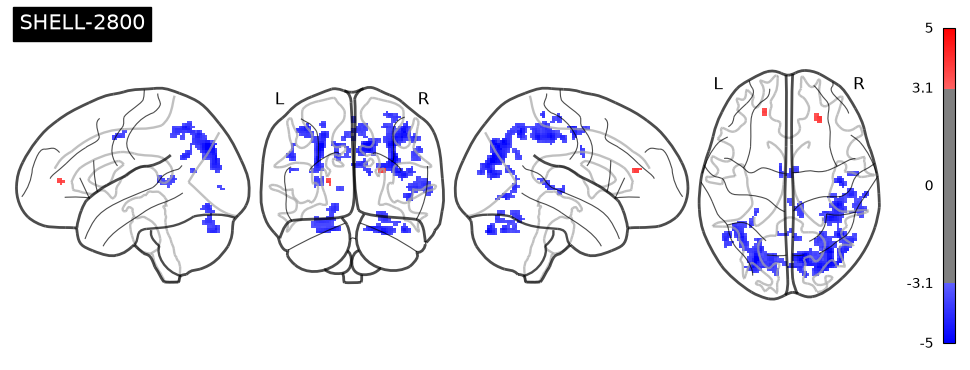

In [93]:
import nibabel as nib
from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_design_matrix, plot_glass_brain, show
from nilearn import image as nimg

n_subjects = len(vps)
condition_effect = np.hstack(([1] * n_subjects, [0] * n_subjects))
subject_effect = np.vstack((np.eye(n_subjects), np.eye(n_subjects)))
subjects = [f"S{i:02d}" for i in range(1, n_subjects + 1)]

paired_design_matrix = pd.DataFrame(
    np.hstack((condition_effect[:, np.newaxis], subject_effect)),
    columns=["PORCa_ws_MADONNA", *subjects],
)

fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
plot_design_matrix(paired_design_matrix, rescale=False, axes=ax)
ax.set_title("Paired design", fontsize=12)
derivatives = os.path.join(PRJ_path, 'derivatives')

out_dir = os.path.join(PRJ_path, "Gradient_Analysis")

for SHELL in SHELLs:
    ses01 = os.path.join(out_dir, f"ses-01_signal-drift_ABC_corr_b-{SHELL}_2MNI6mm.nii.gz")
    ses02 = os.path.join(out_dir, f"ses-02_signal-drift_ABC_corr_b-{SHELL}_2MNI6mm.nii.gz")

    # Split each 4D nifti (one volume per subject) into a list of 3D images,
    # ordered to match the design matrix: condition=1 block first, condition=0 block second
    ses01_imgs = list(nimg.iter_img(ses01))
    ses02_imgs = list(nimg.iter_img(ses02))
    imgs = ses01_imgs + ses02_imgs  # length == 2 * n_subjects, matches design matrix row order
    len(imgs)
    # ── GLM ───────────────────────────────────────────────────
    model = SecondLevelModel(n_jobs=2, verbose=0)
    model.fit(imgs, design_matrix=paired_design_matrix)

    z_map = model.compute_contrast("PORCa_ws_MADONNA", output_type="z_score")

    thresholded_map1, threshold1 = threshold_stats_img(
        z_map,
        alpha=0.001,
        # height_control="fdr",
        cluster_threshold=10,
        two_sided=True,
    )

    display = plot_glass_brain(
        thresholded_map1,              # full z-score map (not per-cluster)
        threshold=3.1,                  # p < .001 uncorrected
        vmax=5,
        vmin=-5,
        symmetric_cbar=True,
        cmap="bwr",
        colorbar=True,
        display_mode="lyrz",            # standard glass-brain multi-view; swap to "ortho" or "z" if you want fewer panels
        black_bg=False,
        plot_abs=False,                 # keep sign (needed since symmetric_cbar + bwr implies +/- distinction)
        title=f"SHELL-{SHELL}",
        
    )
    display.savefig(
        f"/home/malberti/Unix_Folders/SWEEP2/"
        f"Gradients_WoxelWise{SHELL}.png",
        dpi=600,
    )
    show()

## RUN GLM but select random indices: 
-------------------------------------------------

In [ ]:
import nibabel as nib
from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_design_matrix, plot_glass_brain, show
from nilearn import image as nimg

# ─────────────────────────────────────────────────────────────
# Read bvecs / bvals
# ─────────────────────────────────────────────────────────────

BVECs = r"/home/malberti/Unix_Folders/SWEEP2/derivatives/sub-13/ses-01/dwi/eddy/sub-13_ses-01_dwi_eddy_corrected_ABC_noPA2T1w.eddy_rotated_bvecs"
BVALs = r"/home/malberti/Unix_Folders/SWEEP2/derivatives/sub-13/ses-01/dwi/eddy/sub-13_ses-01_dwi_eddy_corrected_ABC_noPA2T1w.bval"

tolerance = 50

bvecs = np.loadtxt(BVECs)     # (3, N)
bvals = np.loadtxt(BVALs)     # (N,)

GTAB = np.vstack((bvals, bvecs))

print("GTAB shape:", GTAB.shape)


# ─────────────────────────────────────────────────────────────
# Segment shells using VOLUME INDICES
# ─────────────────────────────────────────────────────────────

shell_indices = {}

shells = [0, 500, 1000, 1500, 2000, 2800]

for shell in shells:

    if shell == 0:
        idx = np.where(GTAB[0, :] < tolerance)[0]

    else:
        idx = np.where((GTAB[0, :] >= shell - tolerance) & (GTAB[0, :] <= shell + tolerance))[0]

    shell_indices[shell] = idx
    print(f"b{shell}: {len(idx)} volumes ->  indices {idx}")


b1000_idx = shell_indices[1000]
shuffled = np.random.permutation(b1000_idx)
grp1, grp2, grp3 = np.array_split(shuffled, 3)

GRADIENT_GROUPS = {
    1000: {
        "grp1": grp1,
        "grp2": grp2,
        "grp3": grp3,
    }
}

print("b1000 groups:")
print("grp1:", grp1)
print("grp2:", grp2)
print("grp3:", grp3)

#Same for other shells: 

for shell in [1500, 2000, 2800]:

    idx = shell_indices[shell]
    shuffled = np.random.permutation(idx)

    grp1, grp2 = np.array_split(shuffled, 2)

    GRADIENT_GROUPS[shell] = {
    "grp1": grp1,
    "grp2": grp2,
    }

    print(f"\nb{shell}:")
    print("grp1:", grp1)
    print("grp2:", grp2)

In [ ]:
n_subjects = len(vps)
condition_effect = np.hstack(([1] * n_subjects, [0] * n_subjects))
subject_effect = np.vstack((np.eye(n_subjects), np.eye(n_subjects)))
subjects = [f"S{i:02d}" for i in range(1, n_subjects + 1)]

paired_design_matrix = pd.DataFrame(
    np.hstack((condition_effect[:, np.newaxis], subject_effect)),
    columns=["PORCa_ws_MADONNA", *subjects],
)

fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
plot_design_matrix(paired_design_matrix, rescale=False, axes=ax)
ax.set_title("Paired design", fontsize=12)


===== b1000 =====

grp1:


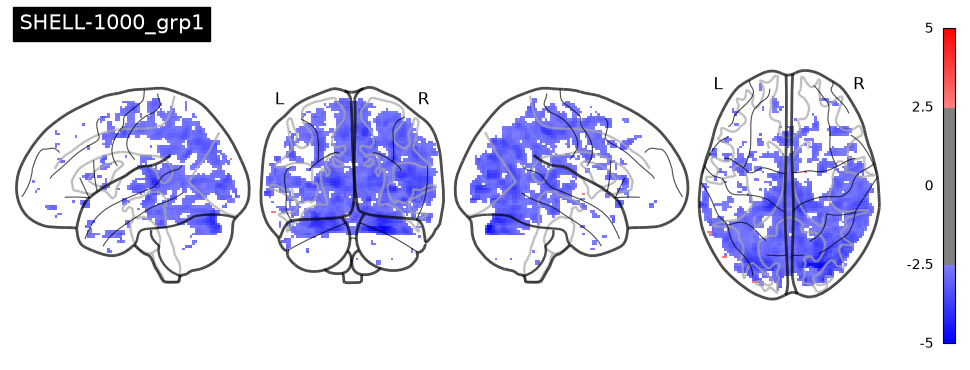


 b1000 grp1 GLM completed (43 subjects)

grp2:


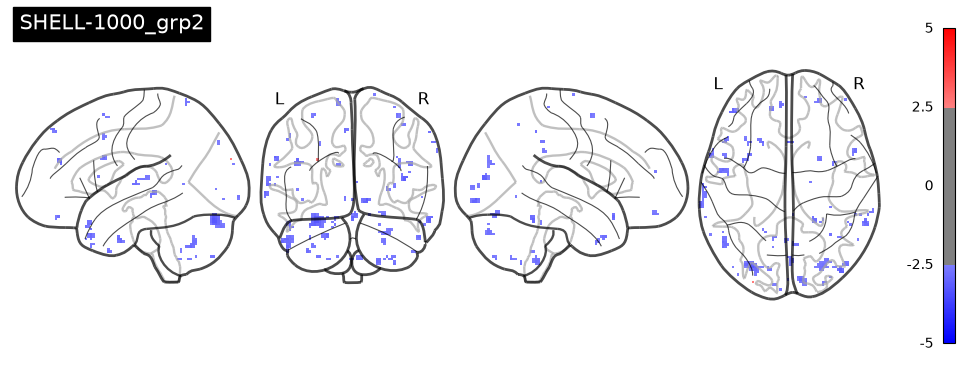


 b1000 grp2 GLM completed (43 subjects)

grp3:


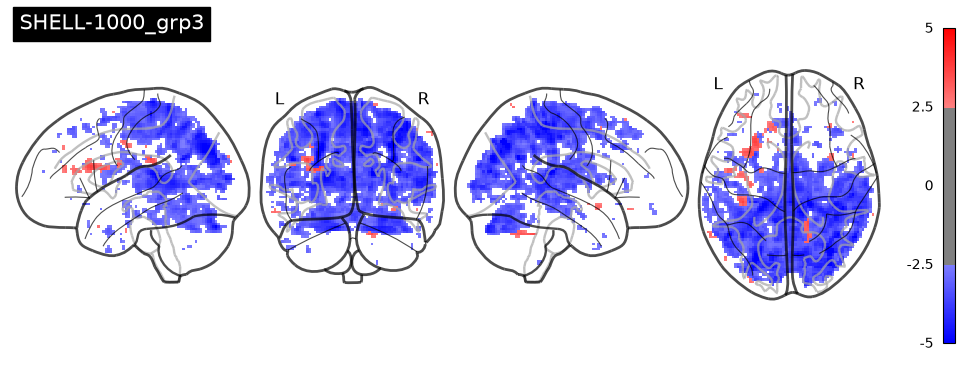


 b1000 grp3 GLM completed (43 subjects)

===== b1500 =====

grp1:


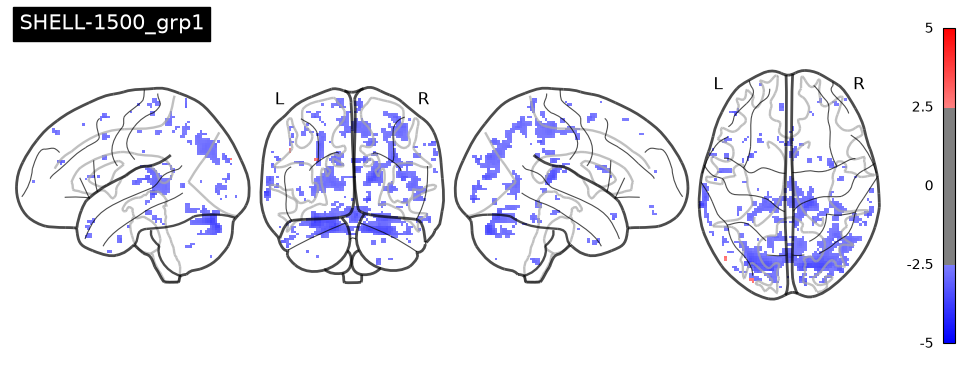


 b1500 grp1 GLM completed (43 subjects)

grp2:


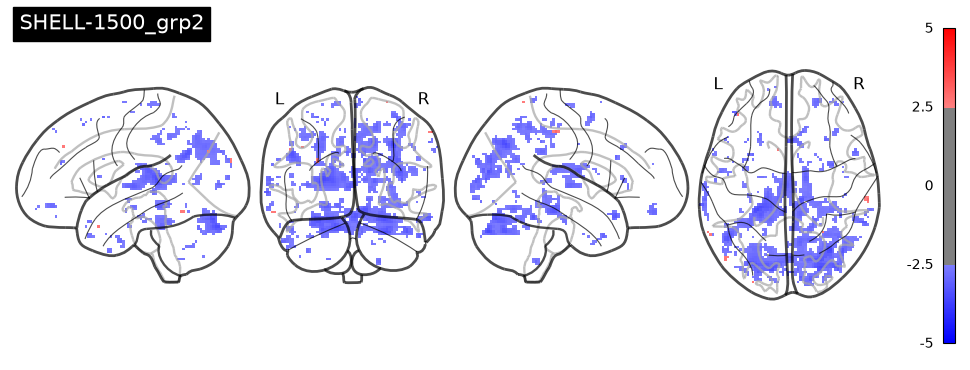


 b1500 grp2 GLM completed (43 subjects)

===== b2000 =====

grp1:


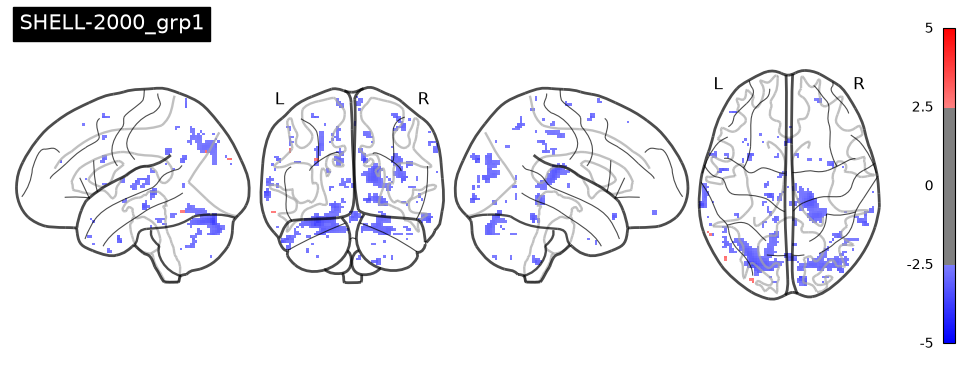


 b2000 grp1 GLM completed (43 subjects)

grp2:


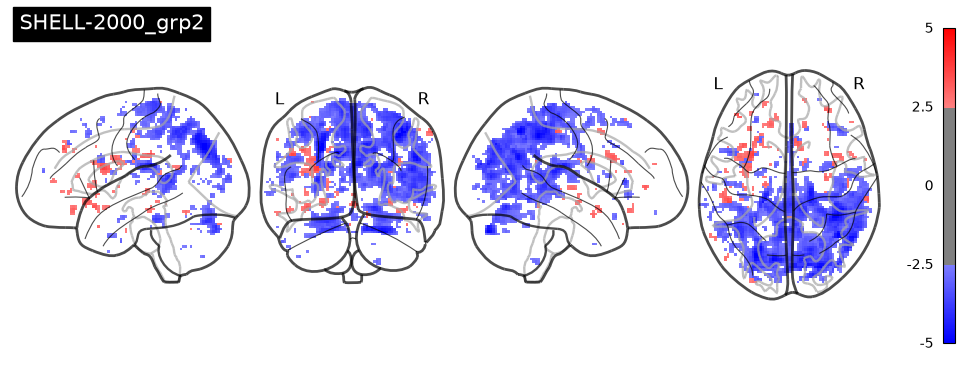


 b2000 grp2 GLM completed (43 subjects)

===== b2800 =====

grp1:


/tmp/ipykernel_2886464/1403314967.py:53: UserWarning: The given float value must not exceed 3.1461957056834753. But, you have given threshold=3.2905267314918945.
  thresholded_map1, threshold1 = threshold_stats_img(


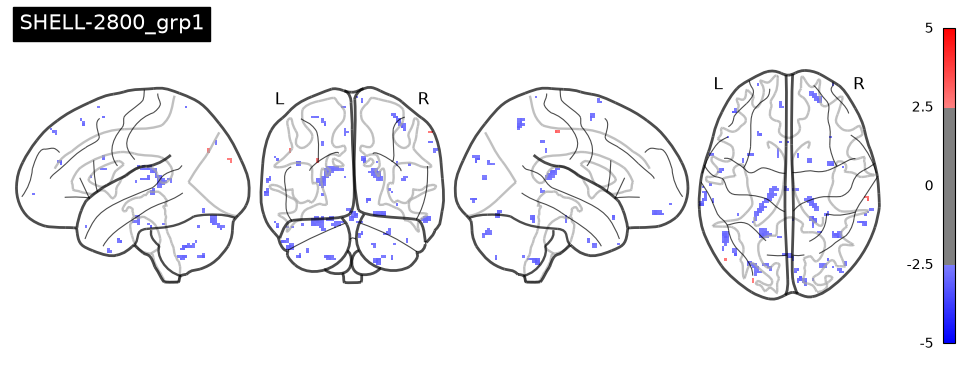


 b2800 grp1 GLM completed (43 subjects)

grp2:


/tmp/ipykernel_2886464/1403314967.py:53: UserWarning: The given float value must not exceed 3.2150529860054675. But, you have given threshold=3.2905267314918945.
  thresholded_map1, threshold1 = threshold_stats_img(


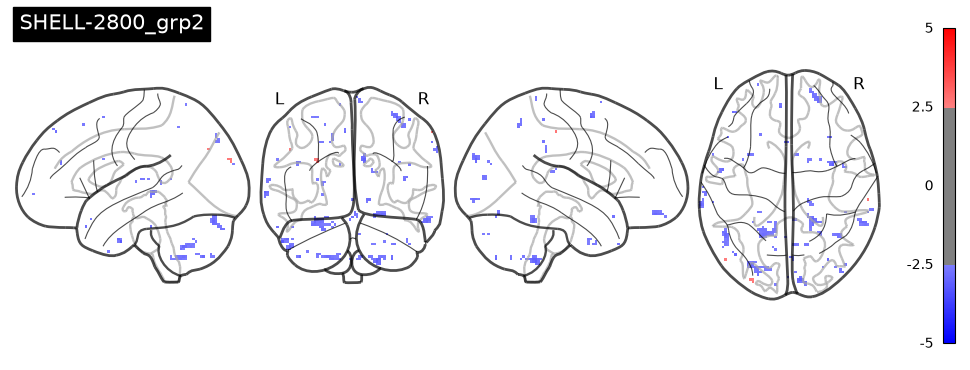


 b2800 grp2 GLM completed (43 subjects)


In [95]:
import os
import numpy as np
import nibabel as nib
from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_glass_brain, show

derivatives = os.path.join(PRJ_path, 'derivatives')
group_dir = os.path.join(PRJ_path, "Gradient_Analysis")

for shell, groups in GRADIENT_GROUPS.items():
    print(f"\n===== b{shell} =====")

    for g, volumes in groups.items():
        print(f"\n{g}:")
        ses01_stack = []
        ses02_stack = []

        for vol in volumes:
            ses01 = os.path.join(group_dir, f"ses-01_signal-drift_ABC_corr_2MNI6mm-vol{vol:04d}_group.nii.gz")
            ses02 = os.path.join(group_dir, f"ses-02_signal-drift_ABC_corr_2MNI6mm-vol{vol:04d}_group.nii.gz")

            ses01_group_data = nib.load(ses01).get_fdata()  # shape (x, y, z, n_subjects)
            ses02_group_data = nib.load(ses02).get_fdata()

            ses01_stack.append(ses01_group_data)
            ses02_stack.append(ses02_group_data)

        # Average across the volumes belonging to this direction-group, per subject —
        # collapses the "which gradient volume within the group" axis while keeping
        # each subject's own map distinct (needed for the paired design matrix below)
        ses01_mean = np.mean(np.stack(ses01_stack, axis=0), axis=0)  # shape (x, y, z, n_subjects)
        ses02_mean = np.mean(np.stack(ses02_stack, axis=0), axis=0)

        ref_img = nib.load(ses01)  # reuse affine/header from the last file loaded in this group
        n_subjects_in_group = ses01_mean.shape[-1]

        ses01_imgs = [nib.Nifti1Image(ses01_mean[..., i], ref_img.affine, ref_img.header) for i in range(n_subjects_in_group)]
        ses02_imgs = [nib.Nifti1Image(ses02_mean[..., i], ref_img.affine, ref_img.header) for i in range(n_subjects_in_group)]

        imgs = ses01_imgs + ses02_imgs  # length == 2 * n_subjects, matches design matrix row order

        if len(imgs) != paired_design_matrix.shape[0]:
            print(f"\n Skipping b{shell} {g}: got {len(imgs)} images, expected {paired_design_matrix.shape[0]}")
            continue

        # ── GLM ───────────────────────────────────────────────────
        model = SecondLevelModel(n_jobs=2, verbose=0)
        model.fit(imgs, design_matrix=paired_design_matrix)

        z_map = model.compute_contrast("PORCa_ws_MADONNA", output_type="z_score")

        thresholded_map1, threshold1 = threshold_stats_img(
            z_map,
            alpha=0.001,
            cluster_threshold=10,
            two_sided=True,
        )

        display = plot_glass_brain(
            z_map,
            threshold=2.5,
            vmax=5,
            vmin=-5,
            symmetric_cbar=True,
            cmap="bwr",
            colorbar=True,
            display_mode="lyrz",
            black_bg=False,
            plot_abs=False,
            title=f"SHELL-{shell}_{g}",
        )
        show()
        display.savefig(
                f"/home/malberti/Unix_Folders/SWEEP2/"
                f"Gradients_WoxelWise{shell}{g}_random_selected.png",
                dpi=600,
            )
        print(f"\n b{shell} {g} GLM completed ({n_subjects_in_group} subjects)")

# Run BETWEEN volume GLM : I restarted from dMRI to MNI coreg
----------------------------

In [ ]:
# Order the volumes:  Each participant has N volumes, i want to order them and compare each volume with itself from other participant. 
# First, create a merged 4D nifti * volume * session

import os
import numpy as np
import nibabel as nib
import utilis

# Prepare the images:

vp_ABC = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 39, 40, 41, 43]
vp_BCA = [18, 19, 20, 21, 23, 24, 22, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 42]

vps = [18, 19, 20, 21, 23, 24, 22, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 42]

SHELLs = [0, 500, 1000, 1500, 2000, 2800]

for vp in vps: 
    for session in sessions:                 
        with tempfile.TemporaryDirectory() as tmp:  # coreg to MNI space each volume
            for AP in APs: 
                pid = f"sub-{vp:02d}"
                subjid = f"{pid}_{session}"
                derivatives = os.path.join(PRJ_path, 'derivatives', pid, session, "dwi")

                DWIs = os.path.join(derivatives, "signal_drift", f"{subjid}_eddy-current_signal-drift_{AP}_corr.nii.gz")
                BVECs = os.path.join(derivatives, "signal_drift", f"{subjid}_dwi_eddy_corrected_{AP}_noPA.eddy_rotated_bvecs")
                BVALs = os.path.join(derivatives, "signal_drift", f"{subjid}_dwi_eddy_corrected_{AP}_noPA.bval")

                # dMRI --> MNI space coregistration + smoothing 
                coreg = os.path.join(derivatives, "coreg")  # dwi --> T1w matrix

                anat = os.path.join(PRJ_path, "derivatives", pid, "ses-02", "anat")  #, id, "mri")
                t1w = os.path.join(anat, "brain-extraction", f"{pid}_ses-02_desc-brain_t1w.nii.gz")
                t1w_mask = os.path.join(anat, "brain-extraction", f"{pid}_ses-02_desc-brain_mask.nii.gz")
                FA2t1w_matrix = os.path.join(coreg, f"{subjid}_{AP}_FA2t1w_0GenericAffine.mat")

                t1w2MNI = os.path.join(anat, "mni-registration", f"{pid}_ses-02_desc-nonlin1warp_xfm.nii.gz")  # Non linear warp 
                t1w2MNI_lin = os.path.join(anat, "mni-registration", f"{pid}_ses-02_desc-nonlin0genericaffine_xfm.mat")

                out_dir = os.path.join(derivatives, "Gradient_Analysis")
                os.makedirs(out_dir, exist_ok=True)

                print(f"\n Subj: {pid} \n Ses: {session} \n Set: {AP} \n ")

                # Clean out any leftover vol*/tt* files from the previous AP before splitting,
                # otherwise a stale file from a prior AP with more volumes can leak into this AP's glob
                for stale in glob.glob(os.path.join(tmp, "vol*")):
                    os.remove(stale)

                subprocess.run(f"fslsplit {DWIs} {os.path.join(tmp, 'vol')}", shell=True, check=True)  # split each volume
                N_volumes = len(glob.glob(os.path.join(tmp, "vol*")))
                count = 1

                for volume in sorted(glob.glob(os.path.join(tmp, "vol*"))): 
                    
                    subprocess.run(f"antsApplyTransforms -d 3 -e 0 -i {volume} -r {TEMPLATE} -o {volume} -n BSpline --transform {t1w2MNI} --transform {t1w2MNI_lin} --transform {FA2t1w_matrix} -v", shell=True)
                    tmp1 = os.path.join(tmp, "tt1.nii.gz")
                    tmp2 = os.path.join(tmp, "tt2.nii.gz")

                    print(f"Smoothing.... \n {count}/{N_volumes}")

                    subprocess.run(f"fslmaths {volume} -mas {TEMPLATE_MASK} -s {l2fwhm[1]} -mas {TEMPLATE_MASK} {tmp1}", shell=True)
                    subprocess.run(f"fslmaths {TEMPLATE_MASK} -s {l2fwhm[1]} -mas {TEMPLATE_MASK} {tmp2}", shell=True)
                    subprocess.run(f"fslmaths {tmp1} -div {tmp2} {volume}", shell=True)

                    count += 1

                smoothed_volumes = " ".join(sorted(glob.glob(os.path.join(tmp, "vol*"))))

                out_DWI_mni = os.path.join(tmp, f"{subjid}_signal-drift_{AP}_corr_2MNI6mm.nii.gz")  # coreg'd + smoothed set, this AP
                subprocess.run(f"mrcat {smoothed_volumes} {out_DWI_mni} -force -debug", shell=True, check=True)

            # NOW merge A, B, C after the set-order alignment: 
            # We now change the AP set in order to match ABC order 
            remap = {"C": "B", "B": "A", "A": "C"}

            mean_ABC = []
            for AP in APs:
                if vp in vp_BCA:
                    new_AP = remap[AP]
                elif vp in vp_ABC:
                    new_AP = AP

                in_DWI_mni = os.path.join(tmp, f"{subjid}_signal-drift_{new_AP}_corr_2MNI6mm.nii.gz")  # coreg'd, aligned to ABC order
                mean_ABC.append(in_DWI_mni)  # build the A, B, C order

            merged_inputs = " ".join(mean_ABC)
            out_DWI = os.path.join(out_dir, f"{subjid}_signal-drift_ABC_corr_2MNI6mm.nii.gz")
            subprocess.run(f"mrcat {merged_inputs} {out_DWI} -force -debug", shell=True, check=True)

            print(f"\nCompleted: {out_DWI}")
            subprocess.run(f"mrinfo {out_DWI} ", shell=True, check=True)

### The blocks Below are re-slice your per-subject 4D files (each already ABC-merged, one volume per gradient direction) by volume index instead of by subject — i.e., instead of "subject 1's volumes 1-43, then subject 2's volumes 1-43", you want "everyone's volume 1 together, everyone's volume 2 together", etc. ---> Followed by MATRIX and GLM 

In [ ]:
# Order sequence by volume: 
# Split into one foder, then merge by volume indexing instead of subjid 
for session in sessions:
    with tempfile.TemporaryDirectory() as tmp:  # holds every subject's split volumes together
        subjids = []  # track subject order so we know what "vol0000 across subjects" means later

        for vp in vps:
            pid = f"sub-{vp:02d}"
            subjid = f"{pid}_{session}"
            subjids.append(subjid)

            derivatives = os.path.join(PRJ_path, 'derivatives', pid, session, "dwi")
            out_dir = os.path.join(derivatives, "Gradient_Analysis")

            print(f"Splitting: {subjid}")
            DWIs = os.path.join(out_dir, f"{subjid}_signal-drift_ABC_corr_2MNI6mm.nii.gz")

            N_volumes = nib.load(DWIs).get_fdata().shape[3]
            volumes_TAG = os.path.join(tmp, f"{subjid}_signal-drift_ABC_corr_2MNI6mm-vol")

            subprocess.run(f"fslsplit {DWIs} {volumes_TAG}", shell=True, check=True)  # split into per-volume files, one subject at a time

        # Now that every subject has been split into tmp, group by volume index across subjects
        group_out_dir = os.path.join(PRJ_path, "Gradient_Analysis")
        os.makedirs(group_out_dir, exist_ok=True)

        for volume in range(N_volumes):  # assumes all subjects have the same N_volumes — see note below
            matching_files = sorted(glob.glob(os.path.join(tmp, f"*signal-drift_ABC_corr_2MNI6mm-vol{volume:04d}.nii*")))
            merged_across_subjects = " ".join(matching_files)

            out_DWI_mni = os.path.join(group_out_dir, f"{session}_signal-drift_ABC_corr_2MNI6mm-vol{volume:04d}_group.nii.gz")
            subprocess.run(f"mrcat {merged_across_subjects} {out_DWI_mni} -force", shell=True, check=True)

            print(f"\n Session: {session} \n Volume index: {volume:04d} \n Merged {len(matching_files)} subjects")

In [ ]:
import nibabel as nib
from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_design_matrix, plot_glass_brain, show
from nilearn import image as nimg

n_subjects = len(vps)
condition_effect = np.hstack(([1] * n_subjects, [0] * n_subjects))
subject_effect = np.vstack((np.eye(n_subjects), np.eye(n_subjects)))
subjects = [f"S{i:02d}" for i in range(1, n_subjects + 1)]

paired_design_matrix = pd.DataFrame(
    np.hstack((condition_effect[:, np.newaxis], subject_effect)),
    columns=["PORCa_ws_MADONNA", *subjects],
)

fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
plot_design_matrix(paired_design_matrix, rescale=False, axes=ax)
ax.set_title("Paired design", fontsize=12)

# Get the number of volumes:
DWIs = os.path.join(PRJ_path, 'derivatives', "sub-04", "ses-01", "dwi", "Gradient_Analysis", f"sub-04_ses-01_signal-drift_ABC_corr_2MNI6mm.nii.gz")
N_volumes = nib.load(DWIs).get_fdata().shape[3]

#Get a 4D image to store results 
ref_shape = nib.load(TEMPLATE).shape
results = np.zeros((N_volumes, *ref_shape))  # one z-score volume per entry

for volume in range(N_volumes): 

    group_dir = os.path.join(PRJ_path, "Gradient_Analysis")

    ses01 = os.path.join(group_dir, f"ses-01_signal-drift_ABC_corr_2MNI6mm-vol{volume:04d}_group.nii.gz")
    ses02 = os.path.join(group_dir, f"ses-02_signal-drift_ABC_corr_2MNI6mm-vol{volume:04d}_group.nii.gz")

    # Split each 4D nifti (one volume per subject) into a list of 3D images,
    # ordered to match the design matrix: condition=1 block first, condition=0 block second
    ses01_imgs = list(nimg.iter_img(ses01))
    ses02_imgs = list(nimg.iter_img(ses02))
    imgs = ses01_imgs + ses02_imgs  # length == 2 * n_subjects, matches design matrix row order
    len(imgs)
    # ── GLM ───────────────────────────────────────────────────
    model = SecondLevelModel(n_jobs=2, verbose=0)
    model.fit(imgs, design_matrix=paired_design_matrix)

    z_map = model.compute_contrast("PORCa_ws_MADONNA", output_type="z_score")

    thresholded_map1, threshold1 = threshold_stats_img(
        z_map,
        alpha=0.001,
        # height_control="fdr",
        cluster_threshold=10,
        two_sided=True,
    )

    display = plot_glass_brain(
        thresholded_map1,              # full z-score map (not per-cluster)
        threshold=3.1,                  # p < .001 uncorrected
        vmax=5,
        vmin=-5,
        symmetric_cbar=True,
        cmap="bwr",
        colorbar=True,
        display_mode="lyrz",            # standard glass-brain multi-view; swap to "ortho" or "z" if you want fewer panels
        black_bg=False,
        plot_abs=False,                 # keep sign (needed since symmetric_cbar + bwr implies +/- distinction)
        title=f"Volume-{volume}|{N_volumes} [alpha=0.01]",
        
    )
    results[volume] =  z_map.get_fdata()
    
    # display.add_contours(HPC_parcel, levels=[0.5], colors="black", linewidths=0.4)
    plt.tight_layout()
    show()

### Parallel GLM 

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from joblib import Parallel, delayed
from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm import threshold_stats_img
from nilearn.plotting import plot_design_matrix, plot_glass_brain, show
from nilearn import image as nimg

n_subjects = len(vps)
condition_effect = np.hstack(([1] * n_subjects, [0] * n_subjects))
subject_effect = np.vstack((np.eye(n_subjects), np.eye(n_subjects)))
subjects = [f"S{i:02d}" for i in range(1, n_subjects + 1)]

paired_design_matrix = pd.DataFrame(
    np.hstack((condition_effect[:, np.newaxis], subject_effect)),
    columns=["PORCa_ws_MADONNA", *subjects],
)

fig, ax = plt.subplots(1, 1, figsize=(8, 6), constrained_layout=True)
plot_design_matrix(paired_design_matrix, rescale=False, axes=ax)
ax.set_title("Paired design", fontsize=12)

# Get the number of volumes:
DWIs = os.path.join(PRJ_path, 'derivatives', "sub-04", "ses-01", "dwi", "Gradient_Analysis", "sub-04_ses-01_signal-drift_ABC_corr_2MNI6mm.nii.gz")
N_volumes = nib.load(DWIs).get_fdata().shape[3]

ref_shape = nib.load(TEMPLATE).shape
group_dir = os.path.join(PRJ_path, "Gradient_Analysis")


def run_glm_for_volume(volume, group_dir, design_matrix):
    """Runs the GLM for a single volume index and returns (volume, z_map_data, affine).
    Isolated as a standalone function so joblib can pickle and dispatch it to a worker process."""
    ses01 = os.path.join(group_dir, f"ses-01_signal-drift_ABC_corr_2MNI6mm-vol{volume:04d}_group.nii.gz")
    ses02 = os.path.join(group_dir, f"ses-02_signal-drift_ABC_corr_2MNI6mm-vol{volume:04d}_group.nii.gz")

    ses01_imgs = list(nimg.iter_img(ses01))
    ses02_imgs = list(nimg.iter_img(ses02))
    imgs = ses01_imgs + ses02_imgs  # length == 2 * n_subjects, matches design matrix row order

    if len(imgs) != design_matrix.shape[0]:
        print(f"\n Skipping volume {volume}: got {len(imgs)} images, expected {design_matrix.shape[0]}")
        return volume, None, None

    model = SecondLevelModel(n_jobs=1, verbose=0)  # n_jobs=1 here — parallelism happens at the volume level instead
    model.fit(imgs, design_matrix=design_matrix)

    z_map = model.compute_contrast("PORCa_ws_MADONNA", output_type="z_score")

    return volume, z_map.get_fdata(), z_map.affine


# ── Run all volumes' GLMs in parallel ───────────────────────────────────────
n_jobs_outer = 15  # use all available cores; set to a specific number if you want to leave headroom

parallel_results = Parallel(n_jobs=n_jobs_outer, verbose=10)(
    delayed(run_glm_for_volume)(volume, group_dir, paired_design_matrix)
    for volume in range(N_volumes)
)

# ── Collect results back into the results array, then plot sequentially ───
results = np.zeros((N_volumes, *ref_shape))
z_affine = None

for volume, z_data, affine in parallel_results:
    if z_data is None:
        continue

    z_map_img = nib.Nifti1Image(z_data, affine=affine)

    thresholded_map1, threshold1 = threshold_stats_img(
        z_map_img,
        alpha=0.001,
        cluster_threshold=10,
        two_sided=True,
    )

    results[volume] = thresholded_map1.get_fdata()  # store thresholded values, not raw z-scores
    z_affine = affine  # assumes all z-maps share the same affine; grab it once

for volume in range(N_volumes):
    if np.all(results[volume] == 0):
        continue  # skipped volume (or genuinely no surviving voxels), nothing to plot

    thresholded_map_img = nib.Nifti1Image(results[volume], affine=z_affine)

    display = plot_glass_brain(
        thresholded_map_img,
        threshold=2.5,
        vmax=5,
        vmin=-5,
        symmetric_cbar=True,
        cmap="bwr",
        colorbar=True,
        display_mode="lyrz",
        black_bg=False,
        plot_abs=False,
        title=f"Volume-{volume}|{N_volumes} [alpha=0.01]",
    )
    plt.tight_layout()
    show()

----------------------------------

[INFO] vol245: fewer than 15 significant voxels, skipping
[INFO] vol246: fewer than 15 significant voxels, skipping
[INFO] vol247: fewer than 15 significant voxels, skipping
[INFO] vol258: fewer than 15 significant voxels, skipping
[INFO] vol263: fewer than 15 significant voxels, skipping
[INFO] vol268: fewer than 15 significant voxels, skipping
[INFO] vol346: fewer than 15 significant voxels, skipping
[INFO] vol356: fewer than 15 significant voxels, skipping
[INFO] vol357: fewer than 15 significant voxels, skipping
[INFO] vol358: fewer than 15 significant voxels, skipping
[INFO] vol359: fewer than 15 significant voxels, skipping
[INFO] vol361: fewer than 15 significant voxels, skipping
[INFO] orientation = ('L', 'A', 'S')


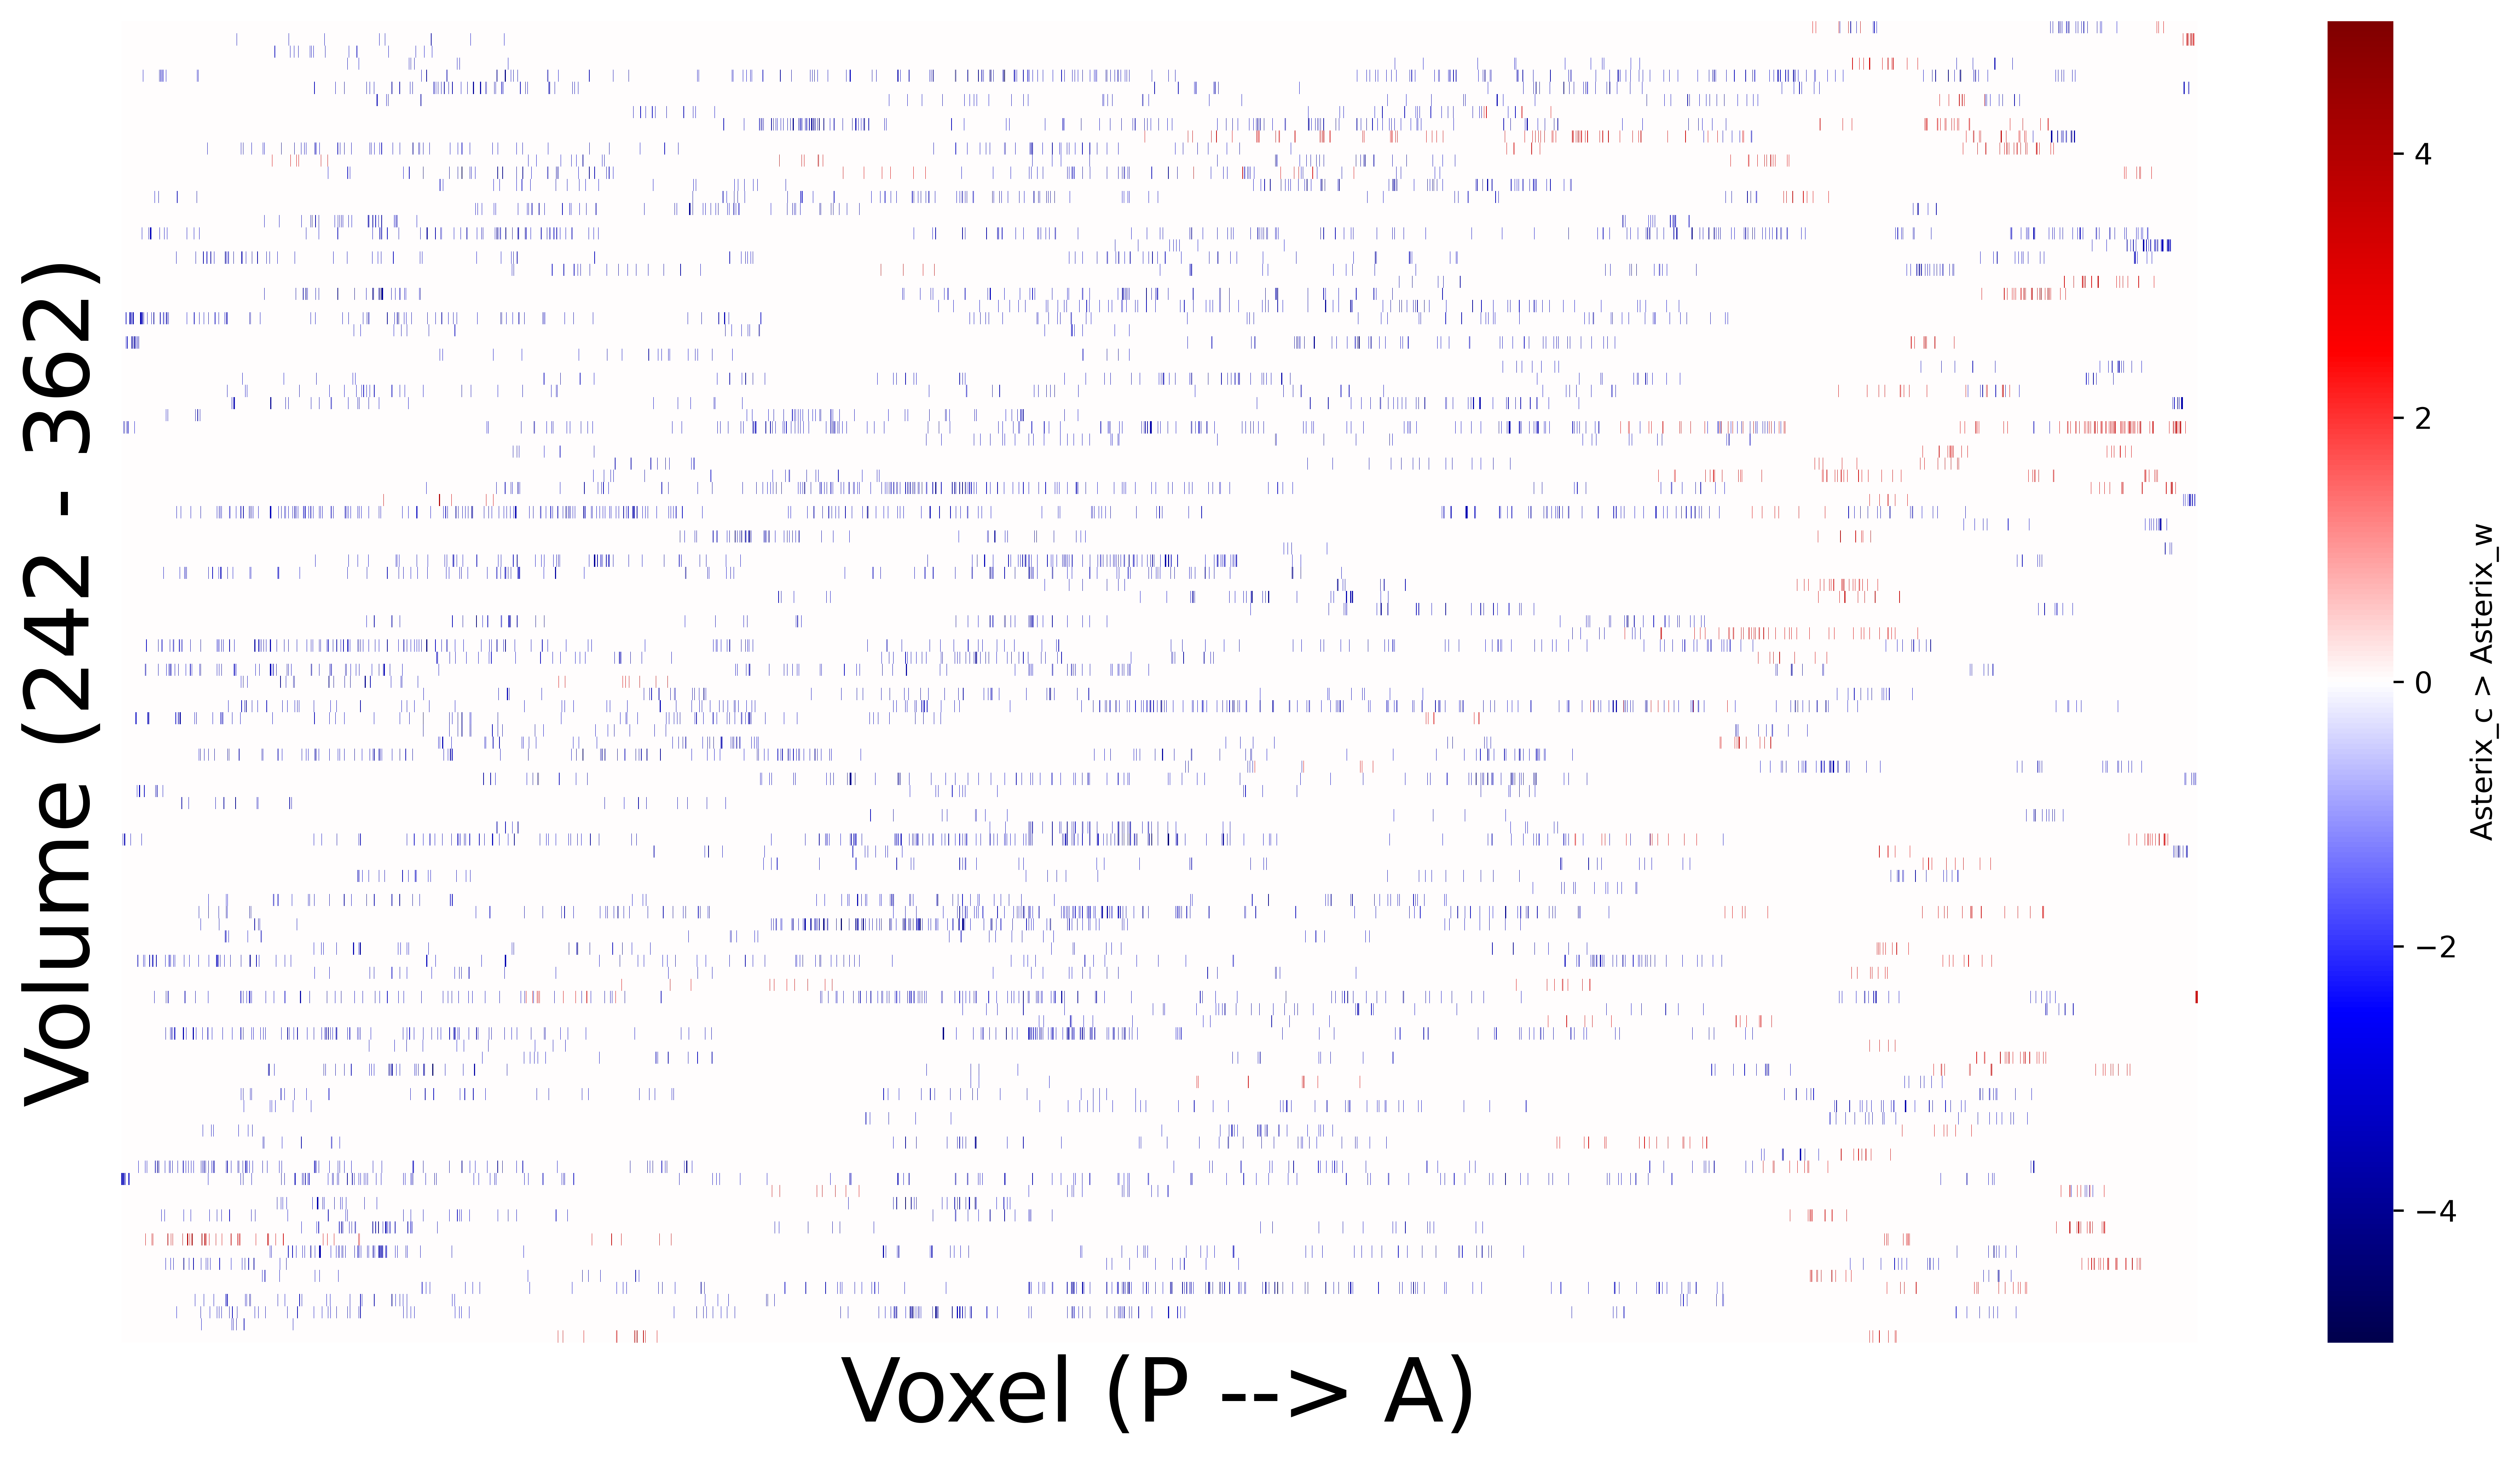

In [ ]:
import os
import numpy as np
import nibabel as nib
from nibabel.affines import apply_affine
import matplotlib.pyplot as plt
import seaborn as sns

ZTHRESH = 2.5
VLIM = 5  # fixed color scale: blue at -5, white/grey at 0, red at +5
MIN_SIG_VOXELS = 15  # matches the threshold intent from the original script

out_dir = os.path.join(PRJ_path, "Gradients_Stability_Analysis")
plot_dir = os.path.join(PRJ_path, "unpaired_ttest_plots")
os.makedirs(plot_dir, exist_ok=True)

REMOVED = 0
rows = []
row_labels = []
shape = ref_shape
affine = z_affine

for volume in range(0,363):
    data = results[volume].copy()  # copy so thresholding here doesn't mutate the shared results array
    #data[(data > -ZTHRESH) & (data < ZTHRESH)] = 0  # keep only |z| beyond ZTHRESH, matching original logic
    row = np.ravel(data)

    if np.count_nonzero(row) < MIN_SIG_VOXELS:
        print(f"[INFO] vol{volume}: fewer than {MIN_SIG_VOXELS} significant voxels, skipping")
        REMOVED += 1
        continue

    rows.append(row)
    row_labels.append(f"vol{volume}")

if not rows:
    print("[WARN] no non-empty volumes, skipping plot")
else:
    axcodes = nib.aff2axcodes(affine)
    print(f"[INFO] orientation = {axcodes}")  # confirm A/P direction before trusting the sign below

    matrix = np.vstack(rows)

    sig_cols = np.any(np.abs(matrix) > ZTHRESH, axis=0)
    original_voxel_indices = np.where(sig_cols)[0]

    matrix = matrix[:, sig_cols]
    voxel_ijk = np.array(np.unravel_index(original_voxel_indices, shape)).T
    voxel_mni = apply_affine(affine, voxel_ijk)
    y_coords = voxel_mni[:, 1]  # anterior-posterior axis: negative = posterior, positive = anterior (if RAS+)

    sort_order = np.argsort(y_coords)  # ascending: most posterior first (left) -> most anterior last (right)
    matrix = matrix[:, sort_order]
    y_sorted = y_coords[sort_order]

    fig, ax = plt.subplots(figsize=(13, 7), dpi=600)

    sns.heatmap(
        matrix,
        cmap="seismic", center=0, vmin=-VLIM, vmax=VLIM,
        cbar=True, cbar_kws={"label": "Asterix_c > Asterix_w"},
        linecolor='black',
        xticklabels=False, yticklabels=False,
        ax=ax, robust=True, annot=False,
        square=False,
    )

    ax.set_title("", fontsize=30)
    ax.set_xlabel("Voxel (P --> A)", fontsize=30)
    ax.set_ylabel(f"Volume (242 - 362)", fontsize=30)

    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, "C_heatmap_unpaired_ttest.png"), dpi = 600)
    plt.show()

In [99]:
import os
import numpy as np
import nibabel as nib
from nibabel.affines import apply_affine
import matplotlib.pyplot as plt
import seaborn as sns

ZTHRESH = 2.5
VLIM = 5  # fixed color scale: blue at -5, white/grey at 0, red at +5
MIN_SIG_VOXELS = 0  # matches the threshold intent from the original script

out_dir = os.path.join(PRJ_path, "Gradients_Stability_Analysis")
plot_dir = os.path.join(out_dir, "unpaired_ttest_plots")
os.makedirs(plot_dir, exist_ok=True)

BVECs = r"/home/malberti/Unix_Folders/SWEEP2/derivatives/sub-13/ses-01/dwi/prep/sub-13_ses-01_dir-PA-AP_part-mag_dwi_ABC.bvec"  # FSL format: 3 rows (x, y, z) x N columns
BVALs = r"/home/malberti/Unix_Folders/SWEEP2/derivatives/sub-13/ses-01/dwi/prep/sub-13_ses-01_dir-PA-AP_part-mag_dwi_ABC.bval"   # FSL format: 1 row x N columns

bvecs = np.loadtxt(BVECs)  # shape (3, N)
bvals = np.loadtxt(BVALs)  # shape (N,)

REMOVED = 0
rows = []
row_labels = []
kept_volume_indices = []  # tracks which volume indices survive filtering, so bvecs/bvals can be sliced the same way
shape = ref_shape
affine = z_affine

for volume in range(N_volumes):
    data = results[volume].copy()  # copy so thresholding here doesn't mutate the shared results array
    #data[(data > -ZTHRESH) & (data < ZTHRESH)] = 0  # keep only |z| beyond ZTHRESH, matching original logic
    row = np.ravel(data)

    if np.count_nonzero(row) < MIN_SIG_VOXELS:
        print(f"[INFO] vol{volume}: fewer than {MIN_SIG_VOXELS} significant voxels, skipping")
        REMOVED += 1
        continue

    rows.append(row)
    row_labels.append(f"vol{volume}")
    kept_volume_indices.append(volume)

if not rows:
    print("[WARN] no non-empty volumes, skipping plot")
else:
    axcodes = nib.aff2axcodes(affine)
    print(f"[INFO] orientation = {axcodes}")  # confirm A/P direction before trusting the sign below

    matrix = np.vstack(rows)

    # Filter bvecs/bvals using the same volume indices kept in matrix's rows
    kept_volume_indices = np.array(kept_volume_indices)
    bvecs_filtered = bvecs[:, kept_volume_indices]  # shape (3, len(rows)) — same column order as matrix's rows
    bvals_filtered = bvals[kept_volume_indices]     # shape (len(rows),)

    print(f"[INFO] bvecs/bvals filtered: kept {len(kept_volume_indices)} / {N_volumes} volumes")

[INFO] orientation = ('L', 'A', 'S')
[INFO] bvecs/bvals filtered: kept 363 / 363 volumes


In [101]:
#Same amtrix 
out_dir = os.path.join(PRJ_path)

out_csv_path = os.path.join(out_dir, "zscore_per_volume_ESMRMb26")

matrix = np.asarray(matrix)
kept_volume_indices = np.asarray(kept_volume_indices)

np.savez_compressed(
    out_csv_path,
    matrix=matrix,
    volume=kept_volume_indices
)

print(f"\nSaved 4D matrix + volume indices to:")



Saved 4D matrix + volume indices to:


In [ ]:
import os
import numpy as np
import pandas as pd

BVALs = matrix  # shape (n_kept_volumes,) — mean z-score per row of matrix
out_dir = os.path.join(PRJ_path, "Gradients_Stability_Analysis")

out_csv_path = os.path.join(out_dir, "zscore_per_volume_ESMRMb26.csv")

df = pd.DataFrame({"volume": kept_volume_indices, "mean_zscore": BVALs.ravel()})
#df.to_csv(out_csv_path, index=False)

print(f"\n Saved {len(df)} rows to {out_csv_path}")

ValueError: Per-column arrays must each be 1-dimensional